<a href="https://colab.research.google.com/github/pdf1802/f1-race-replay/blob/feature%2Fdata-analysis/analysis/notebooks/lap_time_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏎️ Lap Time Prediction Model

## What this notebook does
Builds a machine learning model that predicts F1 lap times based on
tyre compound, tyre age, team, lap number and weather conditions.
We train on multiple races across multiple seasons to make the model
generalizable across different tracks and conditions.

## Why these features?
- TyreLife: older tyres = slower laps (degradation)
- Compound: SOFT/MEDIUM/HARD have different baseline pace and wear rates
- Team: car performance affects lap time independently of tyres
- LapNumber: fuel burns off as race progresses, making the car lighter = faster
- TrackTemp: hotter track = faster degradation, affects grip level
- AirTemp: affects engine and tyre performance
- Rainfall: wet conditions completely change lap time expectations

## Why weather matters
The same tyre compound at lap 10 behaves completely differently in
Bahrain (TrackTemp ~50°C) vs Silverstone (TrackTemp ~25°C, possibly wet).
Without weather our model would be confused by these differences.

## Model choice
We use XGBoost — a gradient boosting algorithm that handles:
- Non-linear relationships (degradation isn't a straight line)
- Mixed feature types (numbers + categories like compound and team)
- Noisy real-world data well
- Interactions between features (e.g. soft tyre + high track temp = extra degradation)

## Target variable
LapTimeSeconds — the lap time in seconds we want to predict

In [1]:
!pip install fastf1 pandas numpy matplotlib seaborn scikit-learn xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('/content/driv/MyDrive/f1_cache',exist_ok=True)
fastf1.Cache.enable_cache('/content/driv/MyDrive/f1_cache')

print("Setup complete")

Mounted at /content/drive
Setup complete


In [3]:
races = [
    # 2023 - first 5 rounds
    (2023, 'Bahrain'), (2023, 'Saudi Arabia'), (2023, 'Australia'),
    (2023, 'Azerbaijan'), (2023, 'Miami'),

    # 2024 - first 5 rounds
    (2024, 'Bahrain'), (2024, 'Saudi Arabia'), (2024, 'Australia'),
    (2024, 'Azerbaijan'), (2024, 'Miami'),

    # 2025 - first 5 rounds
    (2025, 'Bahrain'), (2025, 'Saudi Arabia'), (2025, 'Australia'),
    (2025, 'Azerbaijan'), (2025, 'Miami'),
]

all_laps=[]

for year, race in races:
  try:
    print(f"Loading {year}{race}...")
    session= fastf1.get_session(year, race, 'R')
    session.load(weather=True)

    laps=session.laps.copy()

    #Add weather - merge on closest timestamp
    weather = session.weather_data[['Time','TrackTemp','AirTemp','Rainfall']]
    laps= pd.merge_asof(laps.sort_values('LapStartTime'),weather.sort_values('Time'),left_on='LapStartTime',right_on='Time' )

    #Add race info
    laps['Season']=year
    laps['Race']=race

    all_laps.append(laps)
    print(f" {year} {race} — {len(laps)} laps loaded")
  except:
    print(f"Error loading {year}{race}")

full_data = pd.concat(all_laps, ignore_index=True)
print(f"\nTotal laps loaded: {len(full_data)}")

Loading 2023Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_d

 2023 Bahrain — 1056 laps loaded
Loading 2023Saudi Arabia...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

 2023 Saudi Arabia — 943 laps loaded
Loading 2023Australia...


...

 2025 Australia — 927 laps loaded
Loading 2025Azerbaijan...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

 2025 Azerbaijan — 968 laps loaded
Loading 2025Miami...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

 2025 Miami — 1005 laps loaded

Total laps loaded: 15140


##Data Cleaning

We remove noisy laps before training the model:
- Lap times under 60s or over 130s are errors or anomalies
- First lap on a tyre (TyreLife=1) is always slow duw to the out lap
- TrackStatus != '1' means safety car, yellow flag or red flag - not reprsentative
- Unknown compounds (INTERMEDIATE,WET) sre excluded for now

What remains is only clean, green flag racing laps across all 10 races.

In [4]:
#Convert lap time to seconds
full_data['LapTimeSeconds'] = full_data['LapTime'].dt.total_seconds()

#Clean the data
clean_data= full_data[
    (full_data['LapTimeSeconds']>60) &        # no unrealistic fast laps
    (full_data['LapTimeSeconds']<130) &       # no unrealistic slow laps
    (full_data['TyreLife']>1) &               # remove first lap on tyre
    (full_data['TrackStatus']=='1') &         # green flag laps only
    (full_data['Compound'].isin(['SOFT', 'MEDIUM', 'HARD']))  # known compounds only
][['Driver', 'Team', 'LapNumber', 'LapTimeSeconds',
   'Compound', 'TyreLife', 'Stint',
   'TrackTemp', 'AirTemp', 'Rainfall',
   'Season', 'Race']
].copy()


clean_data=clean_data.dropna()

print(f"Laps before cleaning: {len(full_data)}")
print(f"Laps after cleaning: {len(clean_data)}")
print(f"\nCompound distribution:\n{clean_data['Compound'].value_counts()}")
print(f"\nRaces included:\n{clean_data.groupby(['Season','Race']).size()}")

Laps before cleaning: 15140
Laps after cleaning: 12214

Compound distribution:
Compound
HARD      7986
MEDIUM    3103
SOFT      1125
Name: count, dtype: int64

Races included:
Season  Race        
2023    Australia        759
        Azerbaijan       817
        Bahrain          941
        Miami           1102
        Saudi Arabia     836
2024    Australia        897
        Azerbaijan       883
        Bahrain         1047
        Miami            954
        Saudi Arabia     811
2025    Australia         36
        Azerbaijan       818
        Bahrain         1009
        Miami            475
        Saudi Arabia     829
dtype: int64


## Feature Engineering

XGBoost can't read text like "SOFT" or "Ferrari" directly.
We need to convert categorical features into numbers.
This is called encoding.

- Compound: SOFT=0, MEDIUM=1, HARD=2 (ordered by speed)
- Team: label encoded (each team gets a unique number)
- Rainfall: True/False becomes 1/0

In [38]:
from sklearn.preprocessing import LabelEncoder

# Encode copound with maningful order (soft=0 fastest, hard=2 slowest)
compound_map= {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
clean_data['CompoundEncoded'] = clean_data['Compound'].map(compound_map)

#Encode team
le=LabelEncoder()
clean_data['TeamEncoded'] = le.fit_transform(clean_data['Team'])

#Encoded rainfall
clean_data['RainfallEncoded'] =clean_data['Rainfall'].astype(int)

# Drop BaseLap if it already exists from a previous run
if 'BaseLap' in clean_data.columns:
    clean_data = clean_data.drop(columns=['BaseLap'])
if 'LapDelta' in clean_data.columns:
    clean_data = clean_data.drop(columns=['LapDelta'])

#Calculate each driver's baseline pace per race
baseline=clean_data.groupby(['Driver','Season','Race'])['LapTimeSeconds'].min()
baseline.name= 'BaseLap'
clean_data=clean_data.join(baseline,on=['Driver','Season','Race'])

#Target becomes the delta from their personal best
clean_data['LapDelta'] = clean_data['LapTimeSeconds'] - clean_data['BaseLap']

# Cap delta — more than 5s off baseline = something unusual happening
clean_data = clean_data[clean_data['LapDelta'] <= 5].copy()
clean_data = clean_data[clean_data['LapDelta'] >= 0].copy()

# Approximate fuel load — F1 cars start with ~110kg, burn ~1.8kg per lap
clean_data['FuelLoad'] = 110 - (clean_data['LapNumber'] * 1.8)

print(f"Laps after delta filter: {len(clean_data)}")
print(f"Delta range: {clean_data['LapDelta'].min():.2f}s to {clean_data['LapDelta'].max():.2f}s")

features = ['CompoundEncoded', 'TyreLife', 'TeamEncoded',
            'LapNumber', 'TrackTemp', 'AirTemp', 'RainfallEncoded',
            ]

X = clean_data[features]
y = clean_data['LapDelta']


print("Feature matrix shape:",X.shape)
print("\nSample:")
print(X.head())



Laps after delta filter: 11774
Delta range: 0.00s to 5.00s
Feature matrix shape: (11774, 7)

Sample:
    CompoundEncoded  TyreLife  TeamEncoded  LapNumber  TrackTemp  AirTemp  \
40                0       6.0           11        3.0       31.1     27.3   
41                0       3.0            4        3.0       31.1     27.3   
42                0       6.0           11        3.0       31.1     27.3   
43                0       6.0            4        3.0       31.1     27.3   
44                0       6.0            8        3.0       31.1     27.3   

    RainfallEncoded  
40                0  
41                0  
42                0  
43                0  
44                0  


## Train / Test Split

We split the data into two sets:
- 80% training — the model learns from this
- 20% testing — we use this to evaluate how well it learned

The model never sees the test set during training, so it's
a fair way to measure real performance.

random_state=42 just means the split is reproducible —
anyone running this notebook gets the same split.

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 9419
Testing samples:  2355


## Training the XGBoost Model

XGBoost (Extreme Gradient Boosting) builds hundreds of small decision trees, each one learning from the mistakes of the previous one.
The result is a very accurate mode for tbaular data like ours.

Key parameters:
- n_estimators=500: builds 500 trees
- learning_rate=0.05: each tree contributes a small amount (more stable)
- max_depth=6: how complex each tree can be
- rando_state=42 : reproducible results

In [40]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Train the model
model= XGBRegressor(n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    random_state=42,
                    n_jobs=-1 #use all CPU cores
                    )

model.fit(X_train,y_train)

#Evaluate on test set
y_pred= model.predict(X_test)

mae= mean_absolute_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)

print(f"Mean Absolute Error: {mae:.2f} seconds")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 0.44 seconds
R² Score: 0.6929


## Model Evaluation

MAE (Mean Absolute Error) — average difference between
predicted and real lap times in seconds. Lower is better.

R² Score — how much of the variance in lap times the model
explains. 1.0 = perfect, 0.0 = learned nothing.

The scatter plot below shows predicted vs actual lap times.
A perfect model would have all dots on the diagonal line.

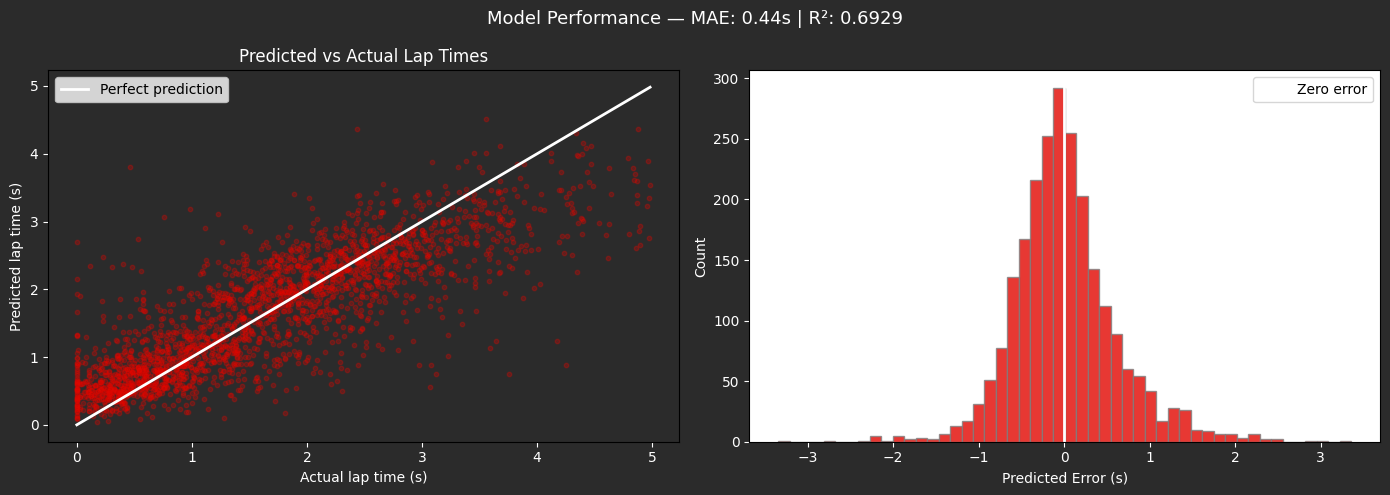

In [41]:
fig, axes= plt.subplots(1,2,figsize=(14,5))

#Plot 1- Predicted vs Actual
axes[0].scatter(y_test,y_pred,alpha=0.3,s=10,color='#E10600')
axes[0].plot([y_test.min(),y_test.max()],
             [y_test.min(),y_test.max()],
             color='white',linewidth=2, label='Perfect prediction'
             )
axes[0].set_xlabel('Actual lap time (s)',color='white')
axes[0].set_ylabel('Predicted lap time (s)',color='white')
axes[0].set_title('Predicted vs Actual Lap Times',color='white')
axes[0].legend()
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#2b2b2b')

#Plot 2 - Error distrribution
errors= y_test-y_pred
axes[1].hist(errors,bins=50,color='#E10600',edgecolor='gray',alpha=0.8)
axes[1].axvline(0,color='white',linewidth=2,label='Zero error')
axes[1].set_xlabel('Predicted Error (s)',color='white')
axes[1].set_ylabel('Count',color='white')
axes[1].legend()
axes[1].tick_params(colors='white')
axes[0].set_facecolor('#2b2b2b')



fig.patch.set_facecolor('#2b2b2b')
plt.suptitle(f'Model Performance — MAE: {mae:.2f}s | R²: {r2:.4f}',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

## Feature Importance

XGBoost tells us which features it relied on most.
This validates our feature choices and tells us if
anything unexpected is driving predictions.

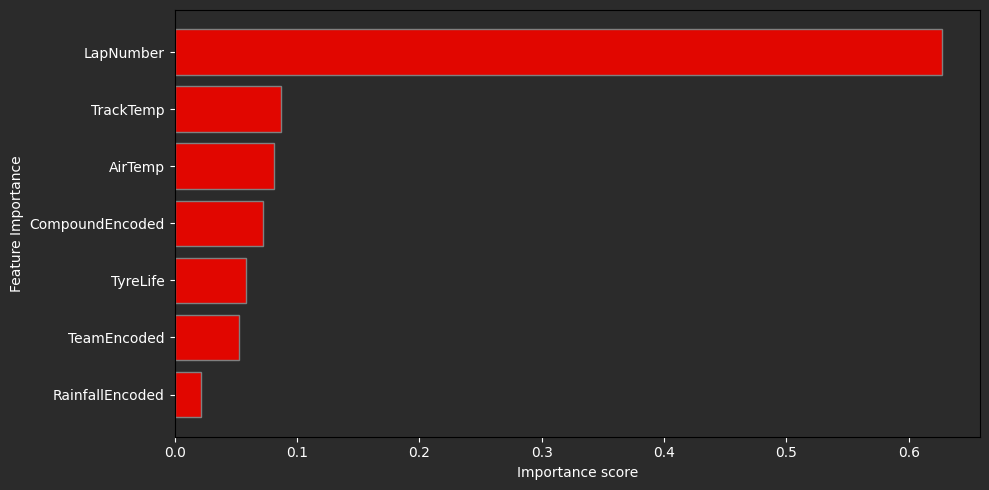

In [42]:
fig, ax= plt.subplots(figsize=(10,5))

importance= model.feature_importances_
feature_names= features

#Sort by importance
sorted_idx = importance.argsort()

ax.barh([feature_names[i] for i in sorted_idx],
        importance[sorted_idx],
        color='#E10600', edgecolor='gray')

ax.set_xlabel('Importance score',color='white')
ax.set_ylabel('Feature Importance',color='white')
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()

## Saving the Model

We save three things to Google Drive:
- lap_time_model.pkl: the trained XGBoost model
- team_encoder.pkl: the LabelEncoder for team names
- compound_map.json: the compound to number mapping

We save these separately because when we use the model
later (in the strategy recommender or simulator) we need
to encode inputs the exact same way the model was trained on.
joblib is the standard way to save/load sklearn and XGBoost models.

In [43]:
import joblib
import os


os.makedirs('/content/drive/MyDrive/f1_models',exist_ok=True)

#Save model
joblib.dump(model, '/content/drive/MyDrive/f1_models/lap_time_model.pkl')

#Save the label encoder so we can use it later
joblib.dump(le, '/content/drive/MyDrive/f1_models/team_encoder.pkl')

#Save the compound map
import json
with open('/content/drive/MyDrive/f1_models/compound_map.json', 'w') as f:
    json.dump(compound_map, f)

print("Model saved succesfuly!")


Model saved succesfuly!


## Testing the Model — Single Lap Prediction

Before building the strategy recommender we verify the model
works correctly by making one manual prediction.

We ask: "How much slower than his personal best will Leclerc be
on lap 30, Medium tyre age 15, in Bahrain conditions?"

The model returns a delta in seconds above his personal best.
A result around 1-2 seconds is realistic for a 15 lap old tyre.

In [44]:
# Predict lap delta for: Leclerc, Ferrari, Lap 30, Medium tyre age 15, Bahrain conditions
test_lap = pd.DataFrame([{
    'CompoundEncoded': compound_map['MEDIUM'],
    'TyreLife': 15,
    'TeamEncoded': le.transform(['Ferrari'])[0],
    'LapNumber': 30,
    'TrackTemp': 38,
    'AirTemp': 28,
    'RainfallEncoded': 0
}])

predicted_delta = model.predict(test_lap)[0]
print(f"Predicted delta from personal best: +{predicted_delta:.2f} seconds")

Predicted delta from personal best: +1.56 seconds


## Strategy Recommender

Uses the trained model to simulate two strategies lap by lap
and recommends the fastest one based on total predicted race time.

How it works:
1. For each strategy, simulate every remaining lap
2. Predict the delta for each lap using the model
3. Add deltas together to get total time cost
4. Compare strategies — lowest total time wins

In [47]:
def simulate_strategy(model,le,compound_map,strategy,
                      current_lap, total_laps,track_temp,
                      air_temp,rainfall=0):
  """
  Simulte a pit stop strategy from current lap to end of race.

  strategy: list of dicts, each describing a stint
  Example: [
    {'compound':'MEDIUM', 'start_lap': 31, 'end_lap': 57}
  ]
  """

  total_delta=0
  lap_by_lap=[]

  for stint in strategy:
    compound= stint['compound']
    start_lap= stint['start_lap']
    end_lap= stint['end_lap']

    for lap in range(start_lap,end_lap+1):
      tyre_age= lap- start_lap +1

      lap_input = pd.DataFrame([{
                'CompoundEncoded': compound_map[compound],
                'TyreLife': tyre_age,
                'TeamEncoded': le.transform(['Ferrari'])[0],
                'LapNumber': lap,
                'TrackTemp': track_temp,
                'AirTemp': air_temp,
                'RainfallEncoded': rainfall
            }])


      delta = model.predict(lap_input)[0]
      total_delta += delta
      lap_by_lap.append({
                'Lap': lap,
                'Compound': compound,
                'TyreAge': tyre_age,
                'PredictedDelta': round(delta, 3)
      })

  return total_delta, pd.DataFrame(lap_by_lap)

# --- SCENARIO: Leclerc, Bahrain, Lap 30, currently on Medium age 15 ---
# Option A: Pit NOW, switch to Hard, run to end (lap 57)
strategy_a = [{'compound': 'HARD', 'start_lap': 31, 'end_lap': 57}]

# Option B: Stay out 5 more laps on Medium, then pit for Hard
strategy_b = [
    {'compound': 'MEDIUM', 'start_lap': 31, 'end_lap': 35},
    {'compound': 'HARD',   'start_lap': 36, 'end_lap': 57}
]

total_a, laps_a = simulate_strategy(
    model, le, compound_map, strategy_a,
    current_lap=30, total_laps=57,
    track_temp=38, air_temp=28
)

total_b, laps_b = simulate_strategy(
    model, le, compound_map, strategy_b,
    current_lap=30, total_laps=57,
    track_temp=38, air_temp=28
)

print(f"Option A (Pit now → Hard): total delta = +{total_a:.2f}s")
print(f"Option B (Stay 5 laps → Hard): total delta = +{total_b:.2f}s")
print()

if total_a < total_b:
    print(f" Recommendation: PIT NOW — saves {total_b - total_a:.2f} seconds")
else:
    print(f" Recommendation: STAY OUT — saves {total_a - total_b:.2f} seconds")

Option A (Pit now → Hard): total delta = +17.68s
Option B (Stay 5 laps → Hard): total delta = +18.41s

 Recommendation: PIT NOW — saves 0.73 seconds


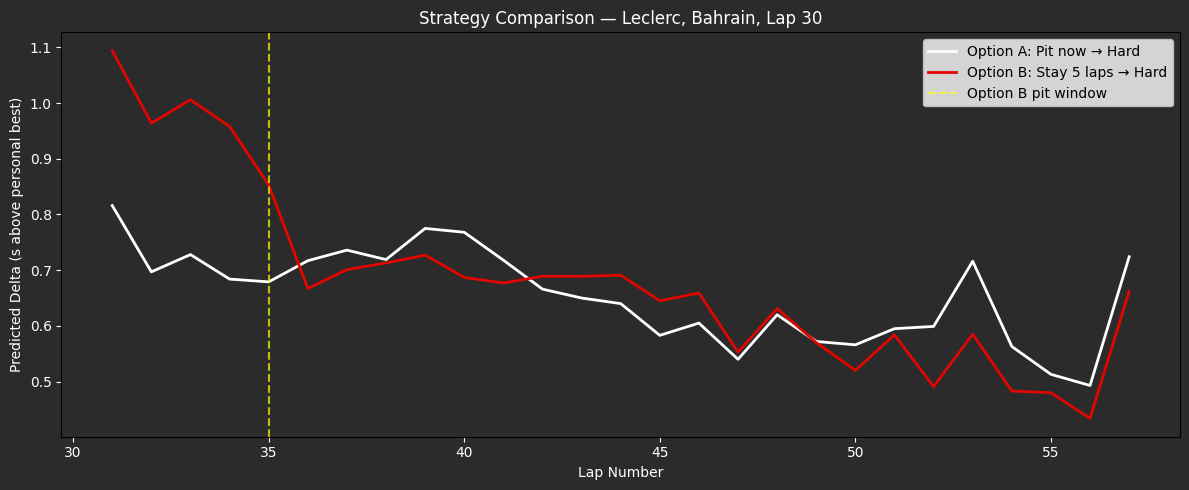

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(laps_a['Lap'], laps_a['PredictedDelta'],
        color='#FFFFFF', label='Option A: Pit now → Hard', linewidth=2)
ax.plot(laps_b['Lap'], laps_b['PredictedDelta'],
        color='#E10600', label='Option B: Stay 5 laps → Hard', linewidth=2)

ax.axvline(x=35, color='yellow', linestyle='--', alpha=0.7, label='Option B pit window')
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Predicted Delta (s above personal best)', color='white')
ax.set_title('Strategy Comparison — Leclerc, Bahrain, Lap 30', color='white')
ax.legend()
ax.tick_params(colors='white')
ax.set_facecolor('#2b2b2b')
fig.patch.set_facecolor('#2b2b2b')
plt.tight_layout()
plt.show()